In [1]:
# --- Imports ---
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.linalg import null_space

In [2]:
# --- Load Data from Previous Steps ---
A = np.load('../data/A_matrix.npy')
A_centered = np.load('../data/A_centered.npy')
player_names = pd.read_csv('../data/player_names.csv').iloc[:, 0].values
features = pd.read_csv('../data/features.csv').iloc[:, 0].values
rank = int(np.load('../data/rank.npy'))

print("Data loaded successfully!")
print(f"Matrix Shape  : {A.shape}")
print(f"Rank          : {rank}")

Data loaded successfully!
Matrix Shape  : (1130, 10)
Rank          : 10


In [3]:
# --- What is Structure of the Space? ---
# Every matrix defines 4 fundamental subspaces:
#   1. Column Space  → span of columns of A
#   2. Row Space     → span of rows of A
#   3. Null Space    → vectors x where Ax = 0
#   4. Left Null Space → vectors y where A^T y = 0
#
# For our project:
#   Row Space    = player preference space (how players relate)
#   Column Space = feature/stat space (how stats relate)
#   Null Space   = hidden/missing patterns in player data

In [4]:
# --- Column Space ---
# The column space is spanned by the columns of A
# Its dimension = rank of A

print("=" * 50)
print("COLUMN SPACE (Feature/Stat Space)")
print("=" * 50)
print(f"Dimension of Column Space = Rank = {rank}")
print(f"\nThe column space spans R^{rank}")
print(f"This means our {rank} stats span a {rank}-dimensional")
print(f"performance space where every player lives.")
print(f"\nBasis of Column Space = first {rank} pivot columns:")
for i, feat in enumerate(features):
    print(f"  e{i+1} → {feat}")

COLUMN SPACE (Feature/Stat Space)
Dimension of Column Space = Rank = 10

The column space spans R^10
This means our 10 stats span a 10-dimensional
performance space where every player lives.

Basis of Column Space = first 10 pivot columns:
  e1 → Matches_Batted
  e2 → Runs_Scored
  e3 → Batting_Average
  e4 → Batting_Strike_Rate
  e5 → Wickets_Taken
  e6 → Economy_Rate
  e7 → Bowling_Average
  e8 → Centuries
  e9 → Half_Centuries
  e10 → Catches_Taken


In [5]:
# --- Row Space ---
# The row space is spanned by the rows of A
# Its dimension also = rank of A
# Each row = one player's performance vector

print("=" * 50)
print("ROW SPACE (Player Preference Space)")
print("=" * 50)
print(f"Dimension of Row Space = Rank = {rank}")
print(f"\nEach player is a vector in R^{A.shape[1]}")
print(f"The row space captures all possible")
print(f"player performance combinations.")
print(f"\nSample player vectors (rows of A):")

for i in range(3):
    print(f"\n  {player_names[i]}:")
    print(f"  {np.round(A[i], 2)}")

ROW SPACE (Player Preference Space)
Dimension of Row Space = Rank = 10

Each player is a vector in R^10
The row space captures all possible
player performance combinations.

Sample player vectors (rows of A):

  Ruturaj Gaikwad:
  [  2.    61.    30.5  119.61   0.     0.     0.     0.     0.     0.  ]

  Ruturaj Gaikwad:
  [ 16.   590.    42.14 147.5    0.     0.     0.     0.     4.    17.  ]

  Ruturaj Gaikwad:
  [ 14.   368.    26.29 126.46   0.     0.     0.     0.     3.     4.  ]


In [6]:
# --- Null Space ---
# Null space = set of all vectors x such that Ax = 0
# Dimension of null space = nullity = num_cols - rank

nullity = A.shape[1] - rank
NS = null_space(A_centered)

print("=" * 50)
print("NULL SPACE (Hidden/Missing Patterns)")
print("=" * 50)
print(f"Nullity (dimension of null space) = {nullity}")

if nullity == 0:
    print("\nNull space contains only the zero vector.")
    print("This means there are NO hidden dependencies")
    print("between player stats — all features carry")
    print("unique independent information!")
else:
    print(f"\nNull space basis vectors shape: {NS.shape}")
    print("These directions cause no change in output —")
    print("hidden redundancies in the data.")

NULL SPACE (Hidden/Missing Patterns)
Nullity (dimension of null space) = 0

Null space contains only the zero vector.
This means there are NO hidden dependencies
between player stats — all features carry
unique independent information!


In [7]:
# --- Rank-Nullity Theorem Verification ---
print("=" * 50)
print("RANK-NULLITY THEOREM VERIFICATION")
print("=" * 50)
print(f"  Number of Columns (n) : {A.shape[1]}")
print(f"  Rank                  : {rank}")
print(f"  Nullity               : {nullity}")
print(f"  Rank + Nullity        : {rank + nullity}")

if rank + nullity == A.shape[1]:
    print("\n  ✅ Rank + Nullity = n → Theorem Verified!")
else:
    print("\n  ❌ Something went wrong!")

RANK-NULLITY THEOREM VERIFICATION
  Number of Columns (n) : 10
  Rank                  : 10
  Nullity               : 0
  Rank + Nullity        : 10

  ✅ Rank + Nullity = n → Theorem Verified!


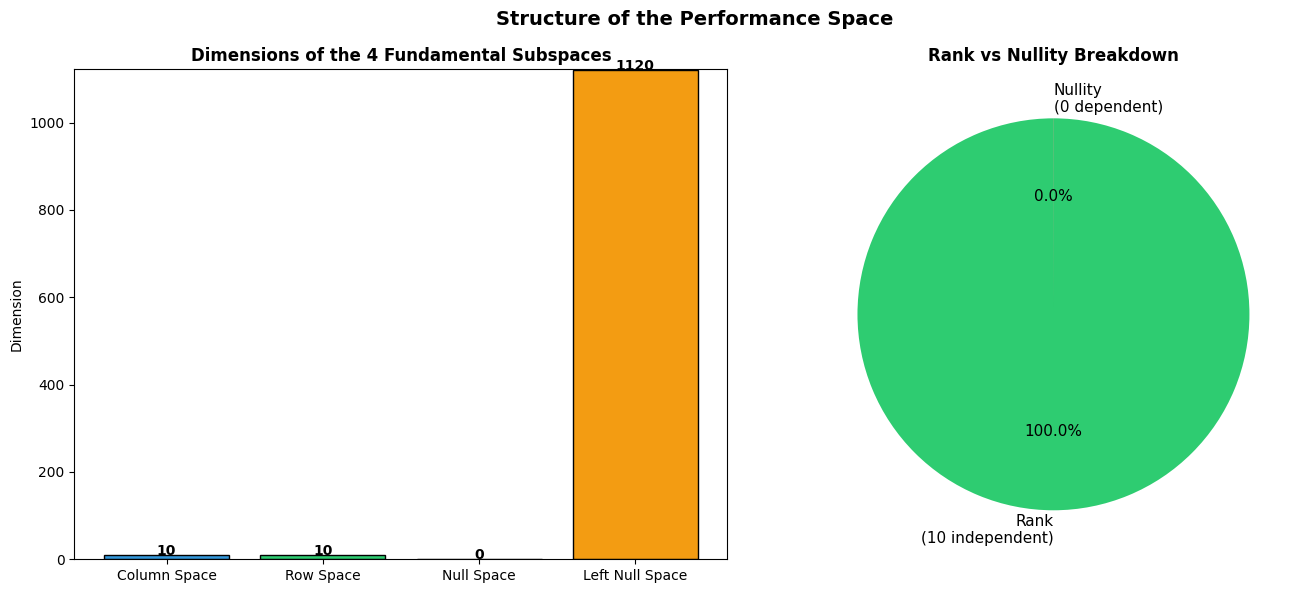

In [8]:
# --- Visualize the 4 Subspaces ---
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Plot 1: Subspace dimensions
subspaces = ['Column Space', 'Row Space', 'Null Space', 'Left Null Space']
dimensions = [rank, rank, nullity, A.shape[0] - rank]
colors = ['#3498db', '#2ecc71', '#e74c3c', '#f39c12']

axes[0].bar(subspaces, dimensions, color=colors, edgecolor='black')
axes[0].set_title('Dimensions of the 4 Fundamental Subspaces',
                  fontweight='bold', fontsize=12)
axes[0].set_ylabel('Dimension')
axes[0].set_ylim(0, max(dimensions) + 2)
for i, v in enumerate(dimensions):
    axes[0].text(i, v + 0.1, str(v), ha='center', fontweight='bold')

# Plot 2: Rank vs Nullity breakdown
axes[1].pie(
    [rank, max(nullity, 0.001)],
    labels=[f'Rank\n({rank} independent)', 
            f'Nullity\n({nullity} dependent)'],
    colors=['#2ecc71', '#e74c3c'],
    autopct='%1.1f%%',
    startangle=90,
    textprops={'fontsize': 11}
)
axes[1].set_title('Rank vs Nullity Breakdown', 
                  fontweight='bold', fontsize=12)

plt.suptitle('Structure of the Performance Space', 
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../outputs/step3_subspaces.png', dpi=150)
plt.show()

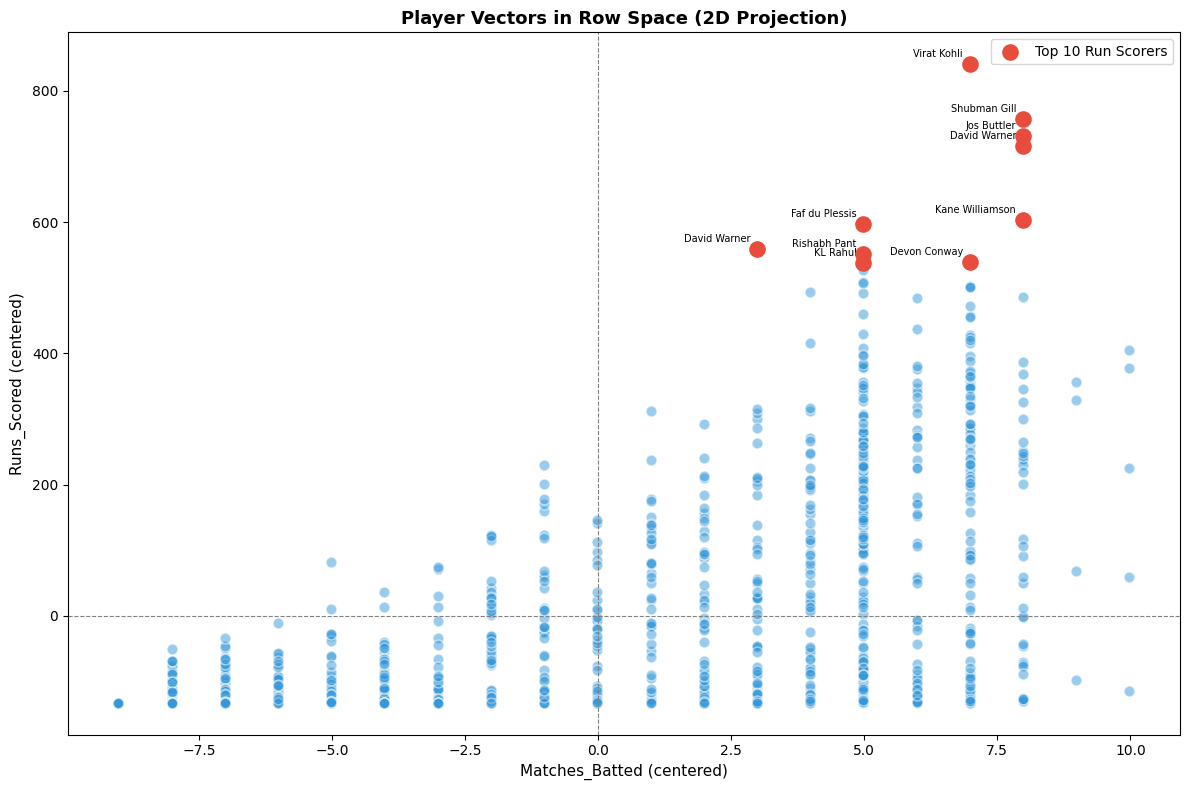

In [9]:
# --- Visualize Player Vectors in 2D (Row Space) ---
# Project all players onto first 2 feature dimensions
# to visualize the row space

fig, ax = plt.subplots(figsize=(12, 8))

x = A_centered[:, 0]  # Matches_Batted
y = A_centered[:, 1]  # Runs_Scored

ax.scatter(x, y, alpha=0.5, color='#3498db', edgecolor='white', s=60)

# Highlight top 10 run scorers
top_idx = np.argsort(A[:, 1])[-10:]
ax.scatter(x[top_idx], y[top_idx], 
           color='#e74c3c', s=120, zorder=5, label='Top 10 Run Scorers')

for i in top_idx:
    ax.annotate(player_names[i], (x[i], y[i]),
                fontsize=7, ha='right',
                xytext=(-5, 5), textcoords='offset points')

ax.axhline(0, color='gray', linewidth=0.8, linestyle='--')
ax.axvline(0, color='gray', linewidth=0.8, linestyle='--')
ax.set_xlabel('Matches_Batted (centered)', fontsize=11)
ax.set_ylabel('Runs_Scored (centered)', fontsize=11)
ax.set_title('Player Vectors in Row Space (2D Projection)', 
             fontweight='bold', fontsize=13)
ax.legend()

plt.tight_layout()
plt.savefig('../outputs/step3_player_row_space.png', dpi=150)
plt.show()

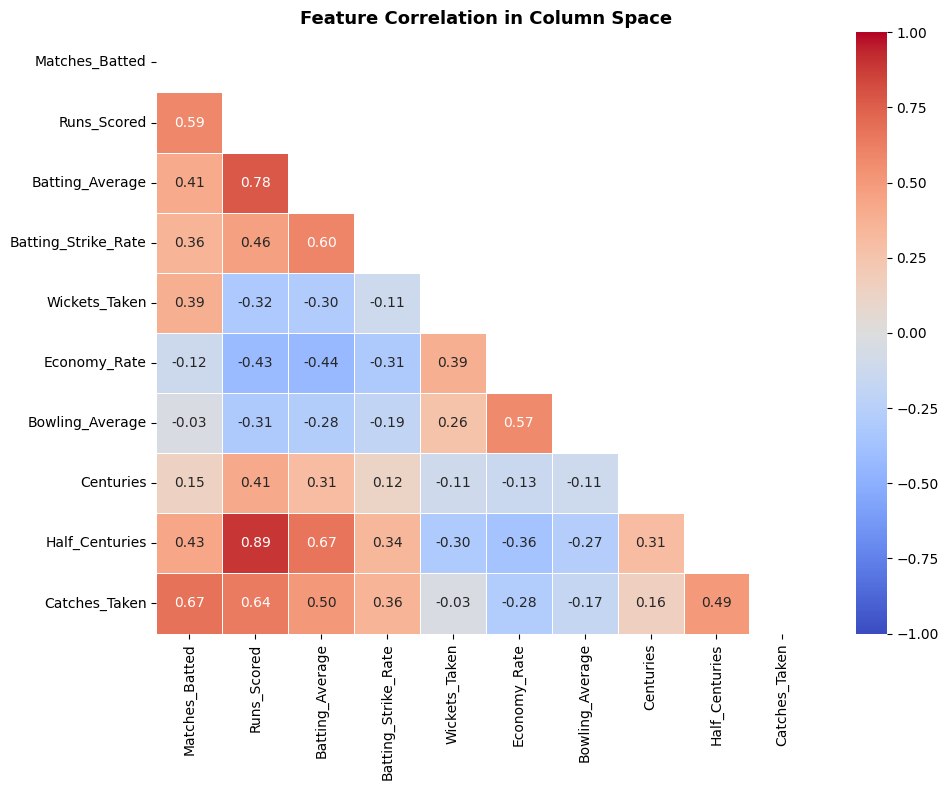

In [10]:
# --- Correlation Heatmap (Column Space Structure) ---
# Shows how features relate to each other
# in the column space

corr = pd.DataFrame(A, columns=features).corr()

plt.figure(figsize=(10, 8))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm',
            mask=mask, linewidths=0.5,
            vmin=-1, vmax=1)
plt.title('Feature Correlation in Column Space',
          fontweight='bold', fontsize=13)
plt.tight_layout()
plt.savefig('../outputs/step3_column_space_correlation.png', dpi=150)
plt.show()

In [11]:
# --- Summary ---
print("=" * 50)
print("STEP 3 SUMMARY — Structure of the Space")
print("=" * 50)
print(f"""
Matrix: {A.shape[0]} players × {A.shape[1]} features

Subspace Dimensions:
  → Column Space  : {rank}  (stat/feature directions)
  → Row Space     : {rank}  (player performance directions)
  → Null Space    : {nullity}  (hidden dependencies)
  → Left Null Space: {A.shape[0] - rank}

Key Insight:
  All {rank} stats are linearly independent.
  Each stat adds unique value to player analysis.
  Players live in a full {rank}-dimensional space.
""")

# Save summary data
np.save('../data/nullity.npy', np.array(nullity))
print("✅ Step 3 Complete!")
print("   → Ready for Step 4: Remove Redundancy")

STEP 3 SUMMARY — Structure of the Space

Matrix: 1130 players × 10 features

Subspace Dimensions:
  → Column Space  : 10  (stat/feature directions)
  → Row Space     : 10  (player performance directions)
  → Null Space    : 0  (hidden dependencies)
  → Left Null Space: 1120

Key Insight:
  All 10 stats are linearly independent.
  Each stat adds unique value to player analysis.
  Players live in a full 10-dimensional space.

✅ Step 3 Complete!
   → Ready for Step 4: Remove Redundancy
